<hr style="border: 1px solid #6c63ff;">
<p style="color:#6c63ff; font-weight:bold;">Gym Data Importation</p>

<span style="background-color:#6c63ff; color:white; padding:3px 10px; border-radius:12px; font-size:13px;">Gender</span>

<h3 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Imports</h3>

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Gym Data Importation</h3>

In [62]:
data = pd.read_csv('gym_membership.csv', index_col = 0)

<h3 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Gym Data Exploration</h3>

In [63]:
data.head()

,gender,birthday,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,name_personal_trainer,uses_sauna
id,,,,,,,,,,,,,,,,
1,Female,1997-04-18,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,NaN,True
2,Female,1977-09-18,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,Chantal,False
3,Male,1983-03-30,41,Premium,1,Sat,True,XCore,08:29:00,10:32:00,123,True,"berry_boost, lemon",True,Mike,False
4,Male,1980-04-12,44,Premium,3,"Sat, Tue, Wed",False,NaN,09:54:00,11:33:00,99,True,passion_fruit,True,Mike,True
5,Male,1980-09-10,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",08:29:00,09:19:00,50,False,NaN,True,Mike,False


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   gender                 1000 non-null   object
 1   birthday               1000 non-null   object
 2   Age                    1000 non-null   int64 
 3   abonoment_type         1000 non-null   object
 4   visit_per_week         1000 non-null   int64 
 5   days_per_week          1000 non-null   object
 6   attend_group_lesson    1000 non-null   bool  
 7   fav_group_lesson       503 non-null    object
 8   avg_time_check_in      1000 non-null   object
 9   avg_time_check_out     1000 non-null   object
 10  avg_time_in_gym        1000 non-null   int64 
 11  drink_abo              1000 non-null   bool  
 12  fav_drink              496 non-null    object
 13  personal_training      1000 non-null   bool  
 14  name_personal_trainer  518 non-null    object
 15  uses_sauna             100

In [65]:
data.describe()

,Age,visit_per_week,avg_time_in_gym
count,1000.000000,1000.000000,1000.000000
mean,30.604000,2.682000,105.260000
std,10.817958,1.241941,43.557177
min,12.000000,1.000000,30.000000
25%,21.000000,2.000000,67.000000
50%,30.000000,3.000000,104.000000
75%,40.000000,3.000000,143.000000
max,49.000000,5.000000,180.000000


In [66]:
data.duplicated().sum()

np.int64(0)

<div style="background-color:#1e1a2e; border-left:5px solid #9b95e0; padding:10px 15px; border-radius:4px;">
    <p style="margin:0; color:#c8c4f0;">Notes in which we have to transform this variables into:</p>
</div>

- Gender - (0/1) , 1 as Male, 0 as Female
- Birthday - Categorize by generations
- Age - Equal, Probably Drop (Redundande with the birthday)
- Subscription type - (0/1) , 1 as Premium, 0 as Standard
- Number of visits per week - Equal
- Which days on the week - Enconding
- Attend group lessons - (0/1) , 1 as 'Yes', 0 as 'No'. Probably Drop (Next columns will say if the client attend group lessons)
- Favortite group lesson - Encoding
- Average time check in - Encoding
- Average time check out - Drop (Redundance since we have the check in and average time in the gym)
- Average time in the gym - Equal
- Drink or not during the workout - (0/1) , 1 being 'Yes', 0 being 'No'. Probably Drop (Next columns will say if the client drinks something)
- Favorite drink - Encoding
- Has a personal trainer - (0/1) , 1 being 'Yes', 0 being 'No'. Probably drop (Next columns will say if the client has a personal trainer)
- Name of the personal trainer - Equal
- Uses sauna - (0/1) , 1 being 'Yes', 0 being 'No'

<h2 style="color:#6c63ff ; border-bottom:3px solid #6c63ff; padding-bottom:8px;">Changes</h2>

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Gender ('gender')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [67]:
data['gender'].unique()

array(['Female', 'Male'], dtype=object)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [68]:
data['gender'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution</p>

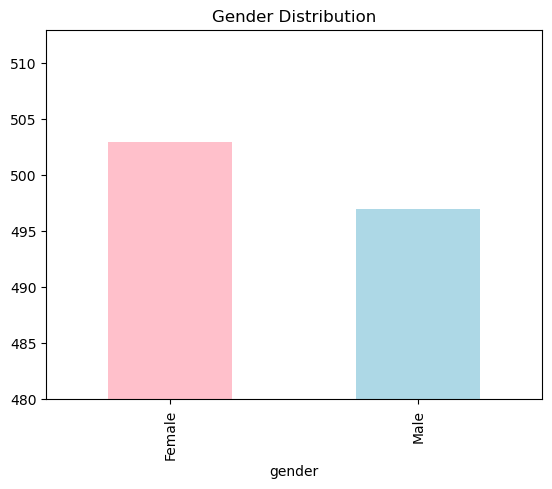

In [69]:
data['gender'].value_counts().plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Gender Distribution')
plt.ylim(480, data['gender'].value_counts().max() + 10)  
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the gender of the client. As it is a categorical variable, 
  frequency encoding was used to convert it into numerical values.</p>

In [70]:
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

<p style="color:#6c63ff; font-weight:bold;display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Birthday ('birthday')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [71]:
data['birthday'].unique()

array(['1997-04-18', '1977-09-18', '1983-03-30', '1980-04-12',
       '1980-09-10', '2009-06-29', '1994-08-07', '2003-11-13',
       '1978-07-28', '2000-05-06', '1983-07-11', '1997-09-19',
       '1994-04-22', '1989-03-21', '1989-10-01', '1987-12-20',
       '1986-12-17', '2011-04-30', '1986-05-29', '1991-09-13',
       '1997-12-31', '1997-10-29', '2010-10-22', '2010-01-24',
       '2008-10-04', '1989-06-17', '2005-03-31', '1992-04-10',
       '1997-01-21', '2002-11-04', '1988-03-04', '2000-03-02',
       '1982-02-26', '1976-12-07', '2004-03-06', '1990-03-09',
       '1981-03-18', '1983-11-01', '1980-07-05', '2006-01-19',
       '2008-06-11', '1989-07-08', '1995-06-26', '1996-04-05',
       '1976-01-19', '1981-05-22', '1989-03-04', '1997-11-15',
       '1975-10-23', '1979-12-29', '1979-07-17', '1996-04-21',
       '2004-07-17', '1980-11-27', '2000-01-04', '2002-07-26',
       '2001-06-12', '1977-12-30', '2007-07-11', '1988-08-20',
       '1977-05-08', '1995-05-13', '1994-03-10', '2002-

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [72]:
data['birthday'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

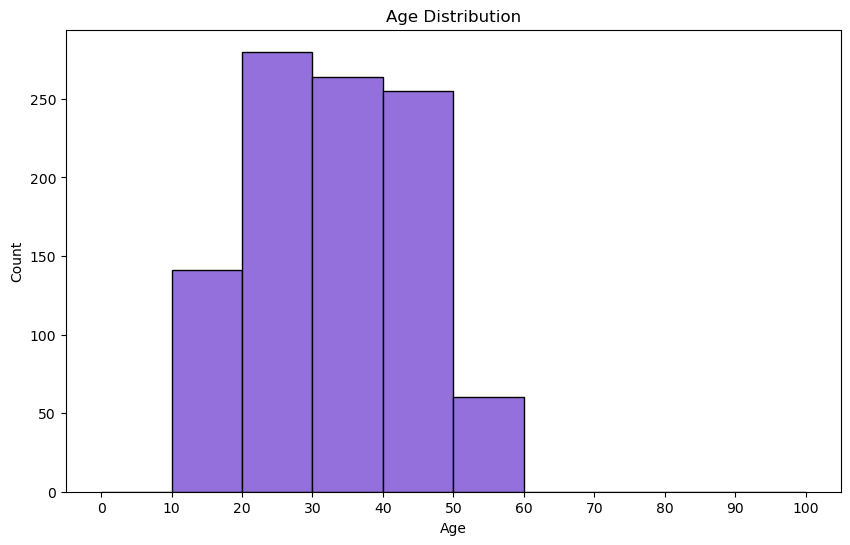

In [73]:
data['age'] = pd.Timestamp.now().year - pd.to_datetime(data['birthday']).dt.year

plt.figure(figsize=(10, 6))
plt.hist(data['age'], bins=range(0, 110, 10), edgecolor='black', color='mediumpurple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(range(0, 110, 10))
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's date of birth. It must be dropped since the age 
column already captures this information.</p>

In [74]:
data.drop(columns=['birthday'], inplace=True)

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Age ('Age')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [75]:
data['Age'].unique()

array([27, 47, 41, 44, 15, 30, 20, 46, 24, 35, 36, 37, 13, 38, 33, 26, 14,
       16, 19, 32, 21, 42, 34, 43, 40, 18, 29, 28, 48, 45, 22, 23, 17, 39,
       31, 12, 49, 25])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [76]:
data['Age'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution</p>

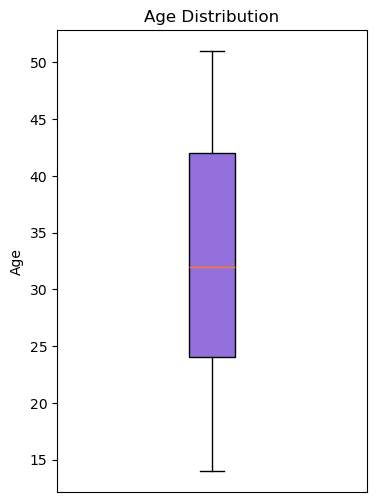

In [77]:
plt.figure(figsize=(4, 6))
plt.boxplot(data['age'].dropna(), patch_artist=True, boxprops=dict(facecolor='mediumpurple'))
plt.title('Age Distribution')
plt.ylabel('Age')
plt.xticks([])
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's age. No transformations were applied to this column.</p>

In [78]:
#data['Age'] = data['Age']

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Subscription ('abonoment_type')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [79]:
data['abonoment_type'].unique()

array(['Premium', 'Standard'], dtype=object)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [80]:
data['abonoment_type'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution values</p>

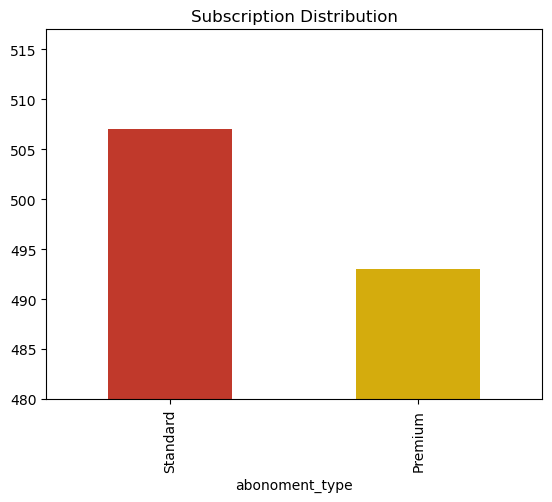

In [81]:
data['abonoment_type'].value_counts().plot(kind='bar', color=['#C0392B', '#D4AC0D'])
plt.title('Subscription Distribution')
plt.ylim(480, data['abonoment_type'].value_counts().max() + 10)  
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents represents which subscription the client as. As it is a categorical variable, 
  frequency encoding was used to convert it into numerical values.</p>

In [82]:
data['abonoment_type'] = data['abonoment_type'].map({'Premium': 1, 'Standard': 0})

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Number of Visits per Week ('visit_per_week')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [83]:
data['visit_per_week'].unique()

array([4, 3, 1, 2, 5])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [84]:
data['visit_per_week'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution values</p>

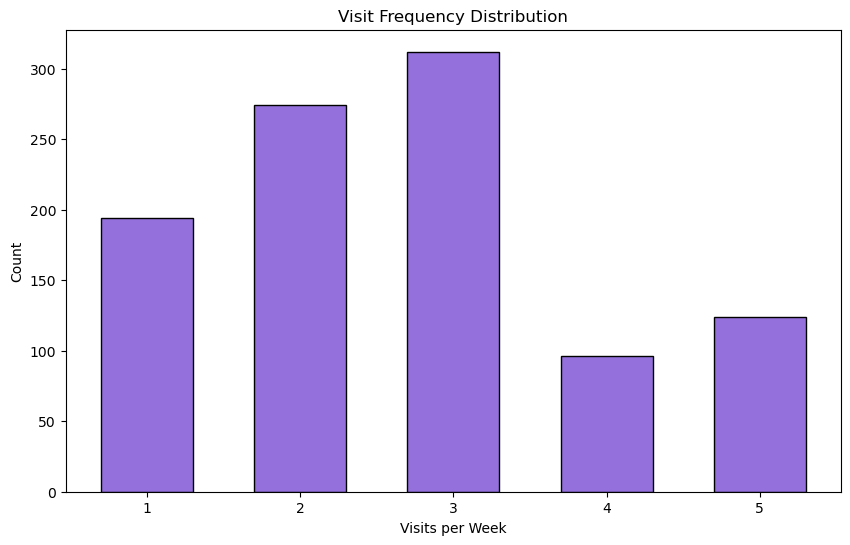

In [85]:
counts = data['visit_per_week'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='mediumpurple', edgecolor='black', width=0.6)
plt.title('Visit Frequency Distribution')
plt.xlabel('Visits per Week')
plt.ylabel('Count')
plt.xticks(range(1, 6))
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the number of visits made by the client. This variable must be droped because the variable of 'days_per_week' already contains this information.</p>

In [86]:
data.drop(columns=['visit_per_week'], inplace=True)

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Days of the week ('days_per_week')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [87]:
data['days_per_week'].unique()

array(['Mon, Sat, Tue, Wed', 'Mon, Sat, Wed', 'Sat', 'Sat, Tue, Wed',
       'Thu, Wed', 'Mon', 'Sat, Thu, Wed', 'Mon, Wed', 'Sat, Sun, Thu',
       'Fri', 'Fri, Thu, Wed', 'Sun, Wed', 'Mon, Tue, Wed',
       'Mon, Thu, Tue, Wed', 'Fri, Sat, Sun', 'Sat, Thu, Tue', 'Tue',
       'Sat, Wed', 'Fri, Mon', 'Fri, Mon, Sat', 'Mon, Tue',
       'Fri, Sun, Wed', 'Fri, Sat, Sun, Tue, Wed', 'Wed', 'Fri, Mon, Thu',
       'Sun, Thu, Wed', 'Fri, Mon, Sat, Sun, Wed', 'Sat, Sun, Tue',
       'Mon, Sat', 'Mon, Sun, Thu, Tue, Wed', 'Sat, Thu', 'Mon, Sun, Tue',
       'Sun', 'Thu', 'Tue, Wed', 'Fri, Mon, Sat, Tue', 'Sun, Tue, Wed',
       'Fri, Mon, Sun, Thu, Tue', 'Fri, Thu, Tue', 'Sat, Tue',
       'Mon, Sun, Thu', 'Sun, Thu', 'Fri, Mon, Sat, Thu', 'Fri, Sun, Tue',
       'Fri, Mon, Sat, Thu, Tue', 'Fri, Tue', 'Mon, Sun, Wed',
       'Fri, Sun, Thu', 'Sun, Tue', 'Fri, Thu, Tue, Wed',
       'Mon, Sat, Sun, Thu, Wed', 'Fri, Mon, Sat, Sun, Tue', 'Fri, Sun',
       'Mon, Sun', 'Fri, Sat, Thu, Tue, Wed', 

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [88]:
data['days_per_week'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution</p>

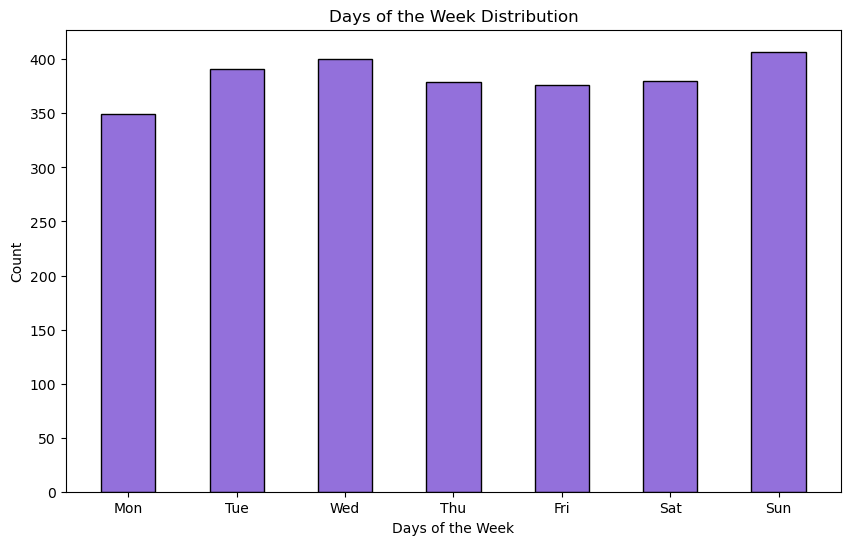

In [89]:
order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
days = (data['days_per_week'].str.split(',').explode().str.strip().value_counts().reindex(order))

plt.figure(figsize=(10, 6))
plt.bar(order, days.values, color='mediumpurple', edgecolor='black', width=0.5) 
plt.title('Days of the Week Distribution')
plt.xlabel('Days of the Week')
plt.ylabel('Count')
plt.xticks(range(0, 7), order)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the days of the week the client visits the gym. Since it is a 
multi-label categorical variable, one-hot encoding was applied, resulting in 7 binary columns, 
one for each day of the week.</p>

In [90]:
days_of_the_week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for day in days_of_the_week:
    data[day] = data['days_per_week'].str.contains(day, case=False, na=False).astype(int)

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Attendance in group lessons ('attend_group_lesson')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [91]:
data['attend_group_lesson'].unique()

array([ True, False])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [92]:
data['attend_group_lesson'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution</p>

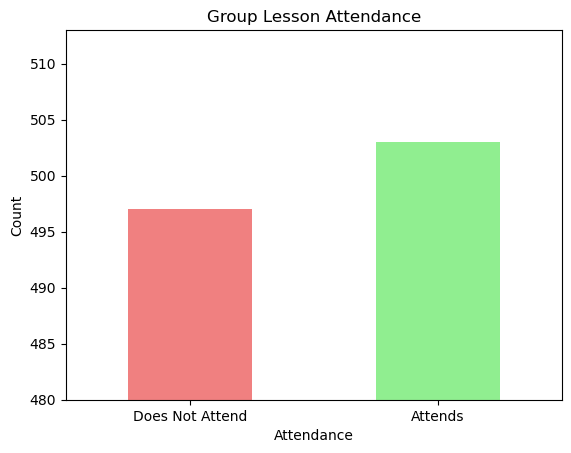

In [93]:
data['attend_group_lesson'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Group Lesson Attendance')
plt.ylim(480, data['attend_group_lesson'].value_counts().max() + 10)
plt.xlabel('Attendance')
plt.ylabel('Count')
plt.xticks([0, 1], ['Does Not Attend', 'Attends'], rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's attendance in group lessons. As it is a boolean 
variable, it was simply converted to 0 and 1.</p>

In [94]:
data['attend_group_lesson'] = data['attend_group_lesson'].map({True: 1, False: 0})

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Favorite group lessons ('fav_group_lesson')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [95]:
data['fav_group_lesson'].unique()

array(['Kickboxen, BodyPump, Zumba', nan, 'XCore', 'Running, Yoga, Zumba',
       'LesMiles, BodyPump', 'Yoga, XCore', 'BodyPump',
       'Pilates, Zumba, XCore', 'XCore, HIT, Running',
       'Spinning, Zumba, XCore', 'Pilates', 'BodyPump, Zumba, Pilates',
       'Yoga, BodyBalance, LesMiles', 'HIT', 'BodyBalance, Zumba, Yoga',
       'Zumba', 'BodyBalance, Pilates, Running',
       'Spinning, BodyPump, Zumba', 'LesMiles, HIT',
       'XCore, Running, BodyBalance', 'LesMiles', 'BodyBalance',
       'Spinning', 'Yoga', 'Yoga, BodyBalance', 'BodyPump, Zumba',
       'BodyPump, Yoga', 'BodyBalance, Running',
       'Spinning, Kickboxen, LesMiles', 'BodyBalance, BodyPump',
       'Kickboxen', 'XCore, Zumba', 'Running',
       'Zumba, Spinning, BodyBalance', 'Yoga, LesMiles, Spinning',
       'Running, Kickboxen', 'Yoga, HIT', 'BodyPump, BodyBalance, XCore',
       'Kickboxen, HIT, BodyPump', 'BodyPump, Spinning, Pilates',
       'BodyPump, Spinning, HIT', 'Pilates, BodyBalance',
       'P

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [96]:
data['fav_group_lesson'].isnull().sum()

np.int64(497)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;"> Distribution</p>

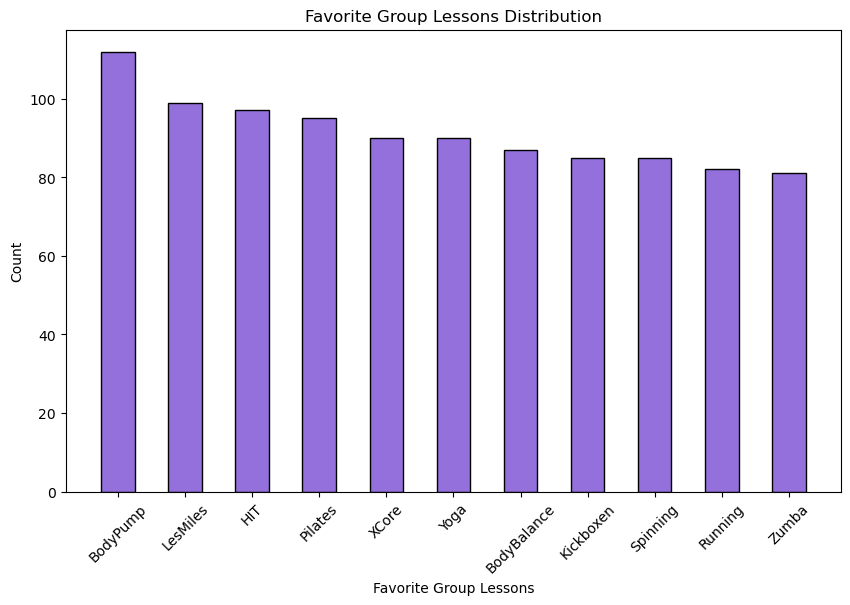

In [97]:
train = (data['fav_group_lesson'].str.split(',').explode().str.strip().value_counts())

plt.figure(figsize=(10, 6))
plt.bar(train.index, train.values, color='mediumpurple', edgecolor='black', width=0.5) 
plt.title('Favorite Group Lessons Distribution')
plt.xlabel('Favorite Group Lessons')
plt.ylabel('Count')
plt.xticks(range(0, 11), train.index, rotation=45)
plt.show()

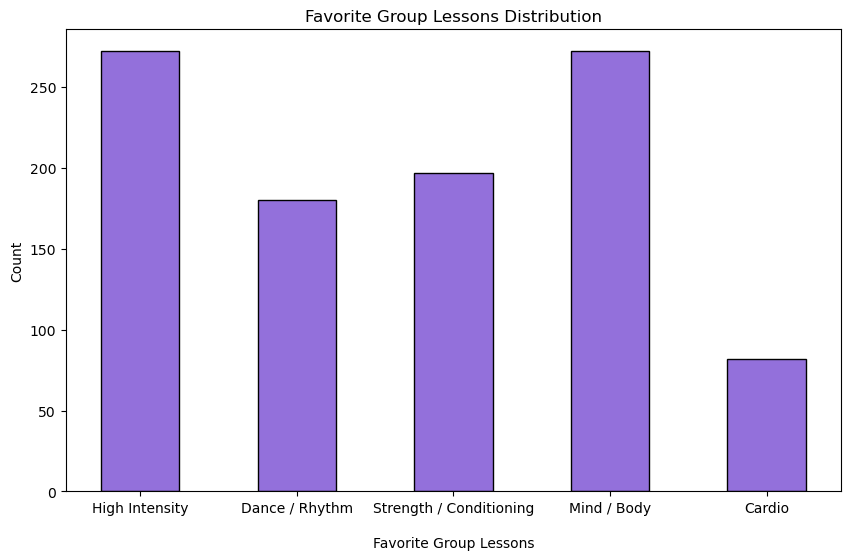

In [98]:
groups = pd.Series(data = 0,index = ['High Intensity', 'Dance / Rhythm', 'Strength / Conditioning', 'Mind / Body', 'Cardio'], name='group')
groups['High Intensity'] = train['Kickboxen'] + train['XCore'] + train['HIT']
groups['Dance / Rhythm'] = train['Zumba'] + train['LesMiles']
groups['Strength / Conditioning'] = train['BodyPump'] + train['Spinning']
groups['Mind / Body'] = train['Yoga'] + train['BodyBalance'] + train['Pilates']
groups['Cardio'] = train['Running']

plt.figure(figsize=(10, 6))
plt.bar(groups.index, groups.values, color='mediumpurple', edgecolor='black', width=0.5) 
plt.title('Favorite Group Lessons Distribution')
plt.xlabel('Favorite Group Lessons', labelpad=15)
plt.ylabel('Count')
plt.xticks(range(0, 5), groups.index, rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's favorite group lesson. Since it is a categorical 
containing which are the favorite group lessons , one-hot encoding was applied.</p>

High Intensity

- Kickboxen
- XCore
- HIT

Dance / Rhythm

- Zumba
- LesMiles

Strength / Conditioning

- BodyPump
- Spinning

Mind / Body

- Yoga
- BodyBalance
- Pilates

Cardio

- Running

In [99]:
high_intensity = ['Kickboxen', 'XCore', 'HIT']
dance = ['Zumba', 'LesMiles']
strength = ['BodyPump', 'Spinning']
mind_body = ['Yoga', 'BodyBalance', 'Pilates']
cardio = ['Running']

for i in data.index:
    
    if pd.isna(data.loc[i,'fav_group_lesson']):
        continue
    
    lessons = [x.strip() for x in data.loc[i, 'fav_group_lesson'].split(',')]

    for lesson in lessons:
        if lesson in high_intensity:
            data.loc[i, 'High Intensity'] = 1
        if lesson in dance:
            data.loc[i, 'Dance/Rhythm'] = 1
        if lesson in strength:
            data.loc[i, 'Strength/Conditioning'] = 1
        if lesson in mind_body:
            data.loc[i, 'Mind/Body'] = 1
        if lesson in cardio:
            data.loc[i, 'Cardio'] = 1       

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Average check in ('avg_time_check_in')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [100]:
data['avg_time_check_in'].unique()

array(['19:31:00', '08:29:00', '09:54:00', '17:19:00', '19:46:00',
       '17:45:00', '09:45:00', '13:05:00', '13:50:00', '10:12:00',
       '17:04:00', '19:50:00', '20:12:00', '17:28:00', '09:25:00',
       '16:54:00', '10:01:00', '13:55:00', '08:19:00', '15:06:00',
       '20:56:00', '14:34:00', '08:42:00', '13:12:00', '15:01:00',
       '19:41:00', '11:25:00', '20:15:00', '20:53:00', '10:23:00',
       '14:42:00', '18:15:00', '13:39:00', '09:02:00', '08:39:00',
       '20:43:00', '10:26:00', '16:04:00', '09:38:00', '10:25:00',
       '11:49:00', '09:57:00', '18:41:00', '15:02:00', '16:29:00',
       '11:56:00', '08:54:00', '09:43:00', '20:58:00', '09:26:00',
       '20:36:00', '15:49:00', '17:13:00', '08:36:00', '12:19:00',
       '10:40:00', '19:38:00', '18:30:00', '10:28:00', '17:22:00',
       '10:41:00', '13:06:00', '08:18:00', '13:04:00', '09:04:00',
       '11:11:00', '10:30:00', '17:06:00', '20:17:00', '15:33:00',
       '15:54:00', '16:16:00', '12:44:00', '18:19:00', '12:35:

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [101]:
data['avg_time_check_in'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;"> Distribution</p>

C:\Users\diogo\AppData\Local\Temp\ipykernel_2860\802341875.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['avg_time_check_in'] = pd.to_datetime(data['avg_time_check_in'])


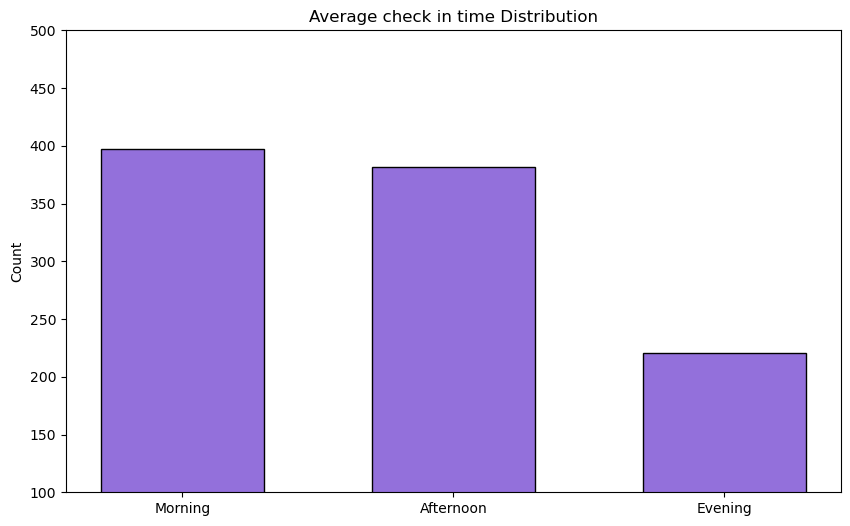

In [102]:
data['avg_time_check_in'] = pd.to_datetime(data['avg_time_check_in'])

time_counts = data['avg_time_check_in'].dt.hour.apply(lambda h: 'Morning' if h <= 12 else 'Afternoon' if h <= 17 else 'Evening').value_counts()

plt.figure(figsize=(10, 6))
plt.bar(time_counts.index, time_counts.values, color='mediumpurple', edgecolor='black', width=0.6)
plt.title('Average check in time Distribution')
plt.ylim(100, 500)  
plt.ylabel('Count')
plt.xticks(range(0,3))
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's average check-in time. Since it is a datetime 
variable, it was grouped into three periods — morning, afternoon and evening — 
and one-hot encoding was applied.</p>

In [103]:
data['avg_time_check_in'] = data['avg_time_check_in'].astype('datetime64[ns]')

In [104]:
data['Morning'] = None
data['Afternoon'] = None
data['Evening'] = None

In [105]:
for i in data.index:
    if pd.isna(data.loc[i, 'avg_time_check_in']):
        continue
    if data.loc[i, 'avg_time_check_in'].hour < 12:
        data.loc[i, 'Morning'] = 1
    elif data.loc[i, 'avg_time_check_in'].hour < 18:
        data.loc[i, 'Afternoon'] = 1
    else:
        data.loc[i, 'Evening'] = 1



<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Average time check out ('avg_time_check_out')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [106]:
data['avg_time_check_out'].unique()

array(['21:27:00', '20:19:00', '10:32:00', '11:33:00', '09:19:00',
       '20:48:00', '19:20:00', '11:17:00', '15:29:00', '14:26:00',
       '10:45:00', '19:42:00', '20:51:00', '22:37:00', '18:29:00',
       '12:06:00', '18:53:00', '12:48:00', '16:24:00', '17:40:00',
       '23:36:00', '16:33:00', '10:34:00', '14:54:00', '16:59:00',
       '21:35:00', '12:56:00', '21:36:00', '12:11:00', '23:33:00',
       '12:01:00', '16:08:00', '20:54:00', '16:20:00', '10:21:00',
       '10:37:00', '22:58:00', '12:13:00', '17:51:00', '10:36:00',
       '12:04:00', '14:11:00', '12:35:00', '16:29:00', '18:45:00',
       '14:13:00', '11:35:00', '11:16:00', '22:20:00', '10:35:00',
       '23:17:00', '18:31:00', '18:24:00', '11:18:00', '12:49:00',
       '21:40:00', '20:17:00', '11:36:00', '17:57:00', '11:38:00',
       '16:22:00', '13:54:00', '11:08:00', '13:37:00', '09:47:00',
       '13:56:00', '13:58:00', '13:27:00', '18:39:00', '23:03:00',
       '12:22:00', '17:01:00', '16:46:00', '18:03:00', '15:44:

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [107]:
data['avg_time_check_out'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

C:\Users\diogo\AppData\Local\Temp\ipykernel_2860\1546248628.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['avg_time_check_out'] = pd.to_datetime(data['avg_time_check_out'])


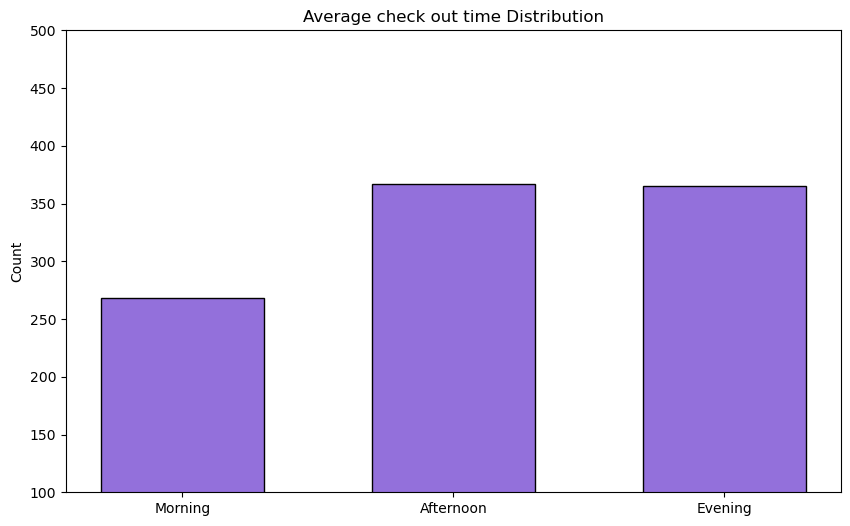

In [108]:
data['avg_time_check_out'] = pd.to_datetime(data['avg_time_check_out'])

time_counts = data['avg_time_check_out'].dt.hour.apply(lambda h: 'Morning' if h <= 12 else 'Afternoon' if h <= 17 else 'Evening').value_counts().reindex(['Morning','Afternoon','Evening'])

plt.figure(figsize=(10, 6))
plt.bar(time_counts.index, time_counts.values, color='mediumpurple', edgecolor='black', width=0.6)
plt.title('Average check out time Distribution')
plt.ylim(100, 500)  
plt.ylabel('Count')
plt.xticks(range(0,3))
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's average check-out time. Since the check-in time 
and average time spent in the gym are already captured, this column was dropped as redundant.</p>

In [109]:
data.drop(columns=['avg_time_check_out'], inplace=True)

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Average time in the gym ('avg_time_in_gym')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [110]:
data['avg_time_in_gym'].unique()

array([116,  48, 123,  99,  50, 180,  62,  95,  92, 144,  36,  33, 158,
        61, 145, 161, 119, 167, 149, 146, 154, 160, 112, 102, 118, 114,
        91,  81, 130,  98,  86, 159,  79, 135, 107,  58, 142, 175,  87,
       136, 137,  93,  82,  69, 162,  71,  30, 122,  68,  35,  57, 147,
       170,  43, 165,  54, 177, 166,  88,  52, 103, 163, 125,  84,  49,
       173,  66, 106,  94,  53, 126,  77, 172, 117, 140,  42, 169,  40,
       156, 104, 178,  56,  67, 143, 108, 151,  73,  85,  83, 100, 174,
        37, 109,  65, 105, 131,  70, 110, 150,  47, 176,  64, 138, 115,
       168,  32,  78,  34, 133,  72,  41,  31,  59, 141,  38,  39, 120,
       153,  89, 128, 179, 132,  44,  51,  97,  75,  96,  60,  76, 124,
       164,  74, 171, 101, 121, 113, 139,  80,  55,  45,  90, 129, 155,
        63, 127, 134, 148, 157, 111,  46, 152])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values </p>

In [111]:
data['avg_time_in_gym'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

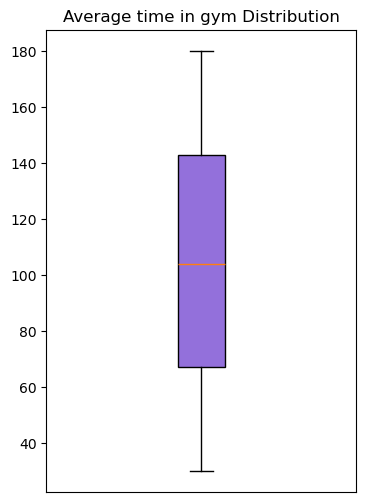

In [112]:
plt.figure(figsize=(4, 6))
plt.boxplot(data['avg_time_in_gym'].dropna(), patch_artist=True, boxprops=dict(facecolor='mediumpurple'))
plt.title('Average time in gym Distribution')
plt.xticks([])
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the client's average time spent in the gym. No transformations 
were applied, although scaling will be performed at a later stage.</p>

In [113]:
#data['avg_time_in_gym'] = data['avg_time_in_gym']

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Drinks during the workout ('drink_abo')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [114]:
data['drink_abo'].unique()

array([False,  True])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [115]:
data['drink_abo'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

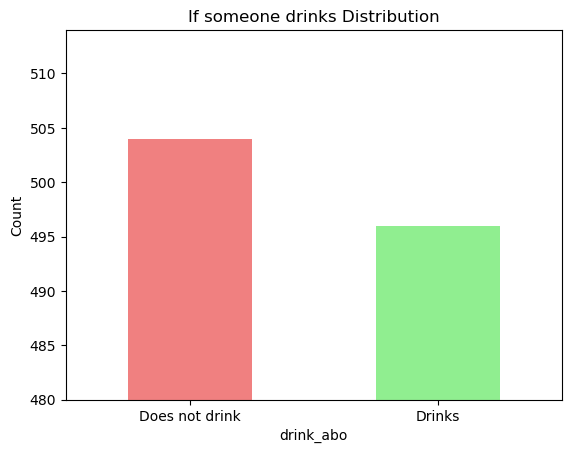

In [116]:
data['drink_abo'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('If someone drinks Distribution')
plt.ylim(480, data['drink_abo'].value_counts().max() + 10)
plt.ylabel('Count')
plt.xticks([0, 1], ['Does not drink', 'Drinks'], rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents if the client drinks something during their gym session. As it is a boolean 
variable, it was simply converted to 0 and 1.</p>

In [117]:
data['drink_abo'] = data['drink_abo'].map({True: 1, False: 0})

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Favorite drinks ('fav_drink')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [118]:
data['fav_drink'].unique()

array([nan, 'berry_boost, lemon', 'passion_fruit', 'coconut_pineapple',
       'orange, lemon', 'black_currant', 'orange, black_currant',
       'orange', 'lemon', 'passion_fruit, orange',
       'lemon, coconut_pineapple', 'berry_boost, passion_fruit',
       'berry_boost', 'orange, coconut_pineapple', 'black_currant, lemon',
       'coconut_pineapple, berry_boost', 'passion_fruit, black_currant',
       'coconut_pineapple, passion_fruit', 'black_currant, passion_fruit',
       'orange, berry_boost', 'passion_fruit, coconut_pineapple',
       'lemon, berry_boost', 'berry_boost, coconut_pineapple',
       'passion_fruit, berry_boost', 'lemon, black_currant',
       'lemon, passion_fruit', 'lemon, orange', 'passion_fruit, lemon',
       'black_currant, coconut_pineapple',
       'coconut_pineapple, black_currant', 'orange, passion_fruit',
       'berry_boost, black_currant', 'berry_boost, orange',
       'coconut_pineapple, orange', 'coconut_pineapple, lemon',
       'black_currant, ora

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [119]:
data['fav_drink'].isnull().sum()

np.int64(504)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

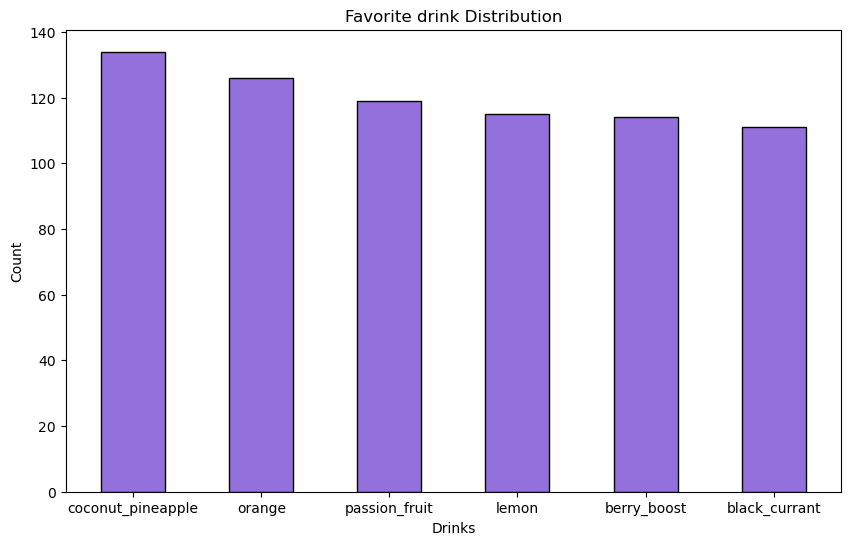

In [120]:
favorite_drinks = (data['fav_drink'].str.split(',').explode().str.strip().value_counts())

plt.figure(figsize=(10, 6))
plt.bar(favorite_drinks.index, favorite_drinks.values, color='mediumpurple', edgecolor='black', width=0.5) 
plt.title('Favorite drink Distribution')
plt.xlabel('Drinks')
plt.ylabel('Count')
plt.xticks(range(0, 6), favorite_drinks.index, rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the favorite drinks of each clients. Since it is a 
multi-label categorical variable, one-hot encoding was applied, resulting in 6 binary columns, 
one for each drink.</p>

In [121]:
data['Berry Boost'] = 0
data['Lemon'] = 0
data['Passion Fruit'] = 0
data['Coconut Pineapple'] = 0
data['Orange'] = 0
data['Black Currant'] = 0

In [122]:
flavours = ['berry_boost', 'lemon', 'passion_fruit', 'coconut_pineapple', 'orange', 'black_currant']

for i in data.index:
    
    if pd.isna(data.loc[i, 'fav_drink']):
        continue

    drinks = [x.strip() for x in data.loc[i, 'fav_drink'].split(',')]
              
    if 'berry_boost' in drinks:
        data.loc[i, 'Berry Boost'] = 1
    if 'lemon' in drinks:
        data.loc[i, 'Lemon'] = 1
    if 'passion_fruit' in drinks:
        data.loc[i, 'Passion Fruit'] = 1
    if 'coconut_pineapple' in drinks:
        data.loc[i, 'Coconut Pineapple'] = 1
    if 'orange' in drinks:
        data.loc[i, 'Orange'] = 1
    if 'black_currant' in drinks:
        data.loc[i, 'Black Currant'] = 1

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Personal training ('personal_training')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [123]:
data['personal_training'].unique()

array([False,  True])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [124]:
data['personal_training'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

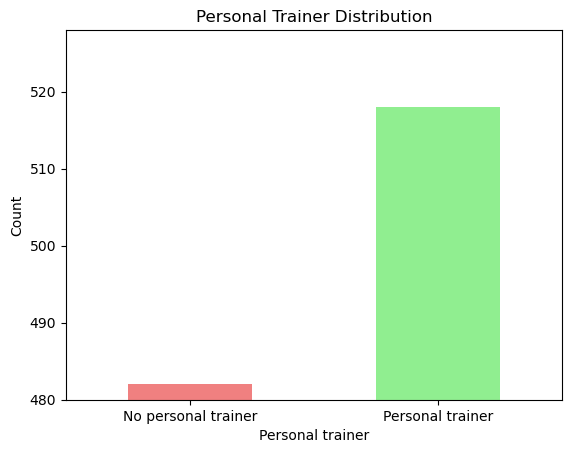

In [125]:
data['personal_training'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Personal Trainer Distribution')
plt.ylim(480, data['personal_training'].value_counts().max() + 10)
plt.ylabel('Count')
plt.xlabel('Personal trainer')
plt.xticks([0, 1], ['No personal trainer', 'Personal trainer'], rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents if the client has a personal trainer. As it is a boolean 
variable, it was simply converted to 0 and 1.</p>

In [126]:
data['personal_training'] = data['personal_training'].map({True: 1, False: 0})

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Personal trainer name ('name_personal_trainer')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [127]:
data['name_personal_trainer'].unique()

array([nan, 'Chantal', 'Mike', 'Jeffrey', 'Hanna'], dtype=object)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [128]:
data['name_personal_trainer'].isnull().sum()

np.int64(482)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

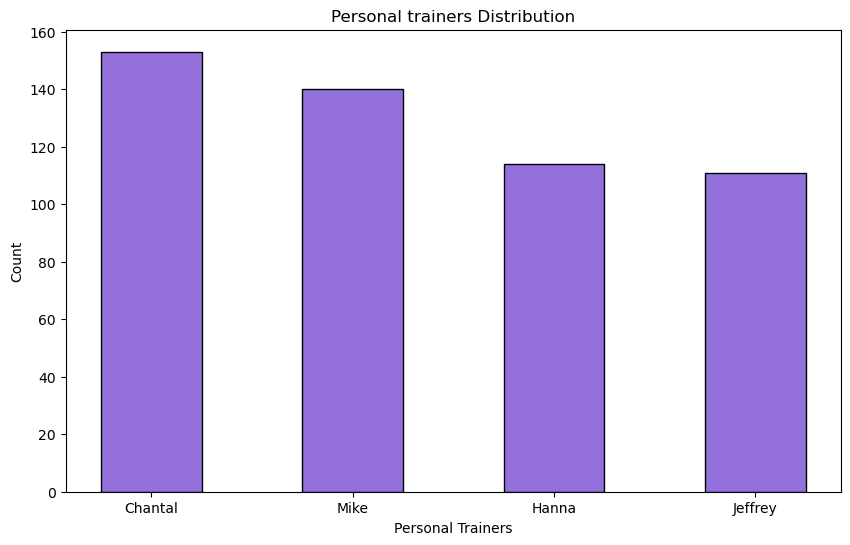

In [129]:
personal_trainers = (data['name_personal_trainer'].dropna().str.split(',').explode().str.strip().value_counts())

plt.figure(figsize=(10, 6))
plt.bar(personal_trainers.index, personal_trainers.values, color='mediumpurple', edgecolor='black', width=0.5) 
plt.title('Personal trainers Distribution')
plt.xlabel('Personal Trainers')
plt.ylabel('Count')
plt.xticks(range(0, 4), personal_trainers.index, rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents the personal trainer of each client. Since it is a 
multi-label categorical variable, one-hot encoding was applied, resulting in 4 binary columns, 
one for each personal trainer.</p>

In [130]:
#data['name_personal_trainer'] = data['name_personal_trainer']

<p style="color:#6c63ff; font-weight:bold; display:inline-block; border-bottom:2px solid #6c63ff; padding-bottom:3px;">Sauna ('uses_sauna')</p>

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Unique values</p>

In [131]:
data['uses_sauna'].unique()

array([ True, False])

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Missing values</p>

In [132]:
data['uses_sauna'].isnull().sum()

np.int64(0)

<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Distribution </p>

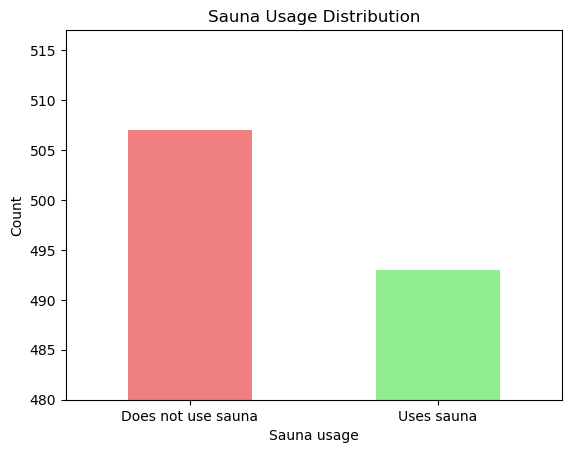

In [133]:
data['uses_sauna'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Sauna Usage Distribution')
plt.ylim(480, data['uses_sauna'].value_counts().max() + 10)
plt.ylabel('Count')
plt.xlabel('Sauna usage')
plt.xticks([0, 1], ['Does not use sauna', 'Uses sauna'], rotation=0)
plt.show()

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">This feature represents if the client uses the sauna. As it is a boolean 
variable, it was simply converted to 0 and 1.</p>

In [134]:
data['uses_sauna'] = data['uses_sauna'].map({True: 1, False: 0})

<h3 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Drop altered columns</h3>

In [135]:
data.head()

,gender,Age,abonoment_type,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_in_gym,drink_abo,fav_drink,...,Mind/Body,Morning,Afternoon,Evening,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant
id,,,,,,,,,,,,,,,,,,,,,
1,0,27,1,"Mon, Sat, Tue, Wed",1,"Kickboxen, BodyPump, Zumba",2026-03-22 19:31:00,116,0,NaN,...,NaN,None,None,1,0,0,0,0,0,0
2,0,47,0,"Mon, Sat, Wed",0,NaN,2026-03-22 19:31:00,48,0,NaN,...,NaN,None,None,1,0,0,0,0,0,0
3,1,41,1,Sat,1,XCore,2026-03-22 08:29:00,123,1,"berry_boost, lemon",...,NaN,1,None,None,1,1,0,0,0,0
4,1,44,1,"Sat, Tue, Wed",0,NaN,2026-03-22 09:54:00,99,1,passion_fruit,...,NaN,1,None,None,0,0,1,0,0,0
5,1,44,0,"Thu, Wed",1,"Running, Yoga, Zumba",2026-03-22 08:29:00,50,0,NaN,...,1.0,1,None,None,0,0,0,0,0,0


In [136]:
data.drop(columns=['days_per_week','fav_group_lesson', 'avg_time_check_in', 'fav_drink'], inplace=True)

In [137]:
for col in data.columns:
    if col == 'Age':
        continue
    if col == 'avg_time_in_gym':
        continue
    print(f"{col} as these unique values: {data[col].unique()}" )

gender as these unique values: [0 1]
abonoment_type as these unique values: [1 0]
attend_group_lesson as these unique values: [1 0]
drink_abo as these unique values: [0 1]
personal_training as these unique values: [0 1]
name_personal_trainer as these unique values: [nan 'Chantal' 'Mike' 'Jeffrey' 'Hanna']
uses_sauna as these unique values: [1 0]
age as these unique values: [29 49 43 46 17 32 23 48 26 37 39 40 15 35 16 18 21 34 24 38 44 50 22 36
 45 20 31 30 51 47 25 19 42 33 14 28 41 27]
Mon as these unique values: [1 0]
Tue as these unique values: [1 0]
Wed as these unique values: [1 0]
Thu as these unique values: [0 1]
Fri as these unique values: [0 1]
Sat as these unique values: [1 0]
Sun as these unique values: [0 1]
High Intensity as these unique values: [ 1. nan]
Strength/Conditioning as these unique values: [ 1. nan]
Dance/Rhythm as these unique values: [ 1. nan]
Cardio as these unique values: [nan  1.]
Mind/Body as these unique values: [nan  1.]
Morning as these unique values: 

In [138]:
data.head()

,gender,Age,abonoment_type,attend_group_lesson,avg_time_in_gym,drink_abo,personal_training,name_personal_trainer,uses_sauna,age,...,Mind/Body,Morning,Afternoon,Evening,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant
id,,,,,,,,,,,,,,,,,,,,,
1,0,27,1,1,116,0,0,NaN,1,29,...,NaN,None,None,1,0,0,0,0,0,0
2,0,47,0,0,48,0,1,Chantal,0,49,...,NaN,None,None,1,0,0,0,0,0,0
3,1,41,1,1,123,1,1,Mike,0,43,...,NaN,1,None,None,1,1,0,0,0,0
4,1,44,1,0,99,1,1,Mike,1,46,...,NaN,1,None,None,0,0,1,0,0,0
5,1,44,0,1,50,0,1,Mike,0,46,...,1.0,1,None,None,0,0,0,0,0,0


<h3 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Missing Values</h3>

In [139]:
for col in data.columns:
    if data[col].isna().sum() > 0:
        print(col)

name_personal_trainer
High Intensity
Strength/Conditioning
Dance/Rhythm
Cardio
Mind/Body
Morning
Afternoon
Evening


Save some space 

In [140]:
"""for i in data.columns:
    if i == 'Average Workout Duration':
        data[i] = data[i].astype('Int16')
    if i == 'Number of Visits per Week':
        data[i] = data[i].astype('Int16')
    

    data[i] = data[i].astype('Int8')
"""

"for i in data.columns:\n    if i == 'Average Workout Duration':\n        data[i] = data[i].astype('Int16')\n    if i == 'Number of Visits per Week':\n        data[i] = data[i].astype('Int16')\n\n\n    data[i] = data[i].astype('Int8')\n"

In [141]:
data.isnull().any().any()  # False = no missing values anywhere

np.True_

In [142]:
#data.to_csv('clean_gym_membership.csv', index=False)

In [143]:
data.head()

,gender,Age,abonoment_type,attend_group_lesson,avg_time_in_gym,drink_abo,personal_training,name_personal_trainer,uses_sauna,age,...,Mind/Body,Morning,Afternoon,Evening,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant
id,,,,,,,,,,,,,,,,,,,,,
1,0,27,1,1,116,0,0,NaN,1,29,...,NaN,None,None,1,0,0,0,0,0,0
2,0,47,0,0,48,0,1,Chantal,0,49,...,NaN,None,None,1,0,0,0,0,0,0
3,1,41,1,1,123,1,1,Mike,0,43,...,NaN,1,None,None,1,1,0,0,0,0
4,1,44,1,0,99,1,1,Mike,1,46,...,NaN,1,None,None,0,0,1,0,0,0
5,1,44,0,1,50,0,1,Mike,0,46,...,1.0,1,None,None,0,0,0,0,0,0
